# Ejercicio de programación Regresión Lineal Multiple

# **Data set**

Incumplimiento de clientes de tarjetas de crédito
Esta investigación se centró en el caso de los pagos predeterminados de los clientes en Taiwán y compara la precisión predictiva de la probabilidad de incumplimiento entre seis métodos de minería de datos.
url: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

# **Requerimientos del data set**
# **n>10 m>10000**

In [77]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [78]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2 Regresión lineal con multiples variables



<a id="section4"></a>
### 2.1 Normalización de caracteristicas



In [79]:
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
ruta = "/content/gdrive/MyDrive/IA-Richard-Chavez/laboratorios/laboratorio01/default of credit card clients.xlsx"

data = pd.read_excel(ruta, header=1)

print("Dimensiones:", data.shape)
print(data.head())

Dimensiones: (30000, 25)
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  

In [80]:
#eliminamos el id ya que no nos sirve
data = data.drop("ID", axis=1)

In [81]:
X = data.drop("default payment next month", axis=1)
y = data["default payment next month"]
m = y.size

In [82]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [83]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0          20000    2          2         1   24      2      2     -1     -1   
1         120000    2          2         2   26     -1      2      0      0   
2          90000    2          2         2   34      0      0      0      0   
3          50000    2          2         1   37      0      0      0      0   
4          50000    1          2         1   57     -1      0     -1      0   
...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
29995     220000    1          3         1   39      0      0      0      0   
29996     150000    1          3         2   43     -1     -1     -1     -1   
29997      30000    1          2         2   37      4      3      2     -1   
29998      80000    1          3         1   41      1     -1      0      0   
29999      50000    1          2         1   46      0      0      0      0   

       PAY_5  ...  BILL_AMT3  BILL_AMT4  BILL_AMT5 

Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [84]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [85]:
print(X)

[[ 1.         -1.13672015  0.81016074 ... -0.30806256 -0.31413612
  -0.29338206]
 [ 1.         -0.3659805   0.81016074 ... -0.24422965 -0.31413612
  -0.18087821]
 [ 1.         -0.59720239  0.81016074 ... -0.24422965 -0.24868274
  -0.01212243]
 ...
 [ 1.         -1.05964618 -1.23432296 ... -0.03996431 -0.18322937
  -0.11900109]
 [ 1.         -0.67427636 -1.23432296 ... -0.18512036  3.15253642
  -0.19190359]
 [ 1.         -0.90549825 -1.23432296 ... -0.24422965 -0.24868274
  -0.23713013]]


<a id="section5"></a>
# **2.2 Descenso por el gradiente**



In [86]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento que serian las filas

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [87]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [ 0.22119001 -0.0121562  -0.0070377  -0.01210753 -0.01245836  0.01301714
  0.10637675  0.0245473   0.0136563   0.00471388  0.00545606  0.00146935
 -0.02634454 -0.00754707 -0.00236767 -0.00147934  0.00180862  0.00482152
 -0.00892509 -0.00454082 -0.00190292 -0.00475433 -0.005      -0.00227148]


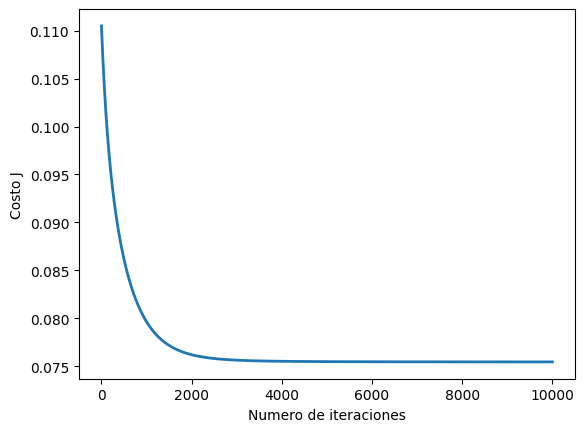

In [88]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))


In [89]:
ejemplo = X[0]

pred = np.dot(ejemplo, theta)

print("Predicción:", pred)

Predicción: 0.46386521395013913


<a id="section7"></a>
# **2.3 Ecuacion de la Normal**

Una manera de calcular rapidamente el modelo de una regresion lineal es:


Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [90]:
# Cargar datos
ruta = "/content/gdrive/MyDrive/IA-Richard-Chavez/laboratorios/laboratorio01/default of credit card clients.xlsx"
data = pd.read_excel(ruta, header=1)
#eliminamos el id ya que no nos sirve
data = data.drop("ID", axis=1)
X = data.drop("default payment next month", axis=1)
y = data["default payment next month"]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

30000


In [91]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [92]:
# Calcular theta con ecuación normal
theta = normalEqn(X, y)

print("Theta calculado con ecuación normal:")
print(theta)

# hacer una predicción con un cliente real
ejemplo = X[0]

pred = np.dot(ejemplo, theta)

print("Predicción para el primer cliente:", pred)

Theta calculado con ecuación normal:
[ 3.14196702e-01 -9.05316482e-08 -1.45313763e-02 -1.51273575e-02
 -2.38215135e-02  1.40949931e-03  9.57054669e-02  1.94561569e-02
  1.16741658e-02  3.36189863e-03  5.69939979e-03  7.92019704e-04
 -6.22465927e-07  1.58703031e-07  3.00530071e-08 -6.79349887e-08
 -2.04872291e-08  1.15259313e-07 -7.43691308e-07 -2.09190755e-07
 -2.87353920e-08 -2.52077019e-07 -3.40958059e-07 -9.76977762e-08]
Predicción para el primer cliente: 0.46331257791124214


# **Conclusión**

En este laboratorio se aplicó la regresión lineal múltiple utilizando el dataset Default of Credit Card Clients del UCI Machine Learning Repository. Se prepararon los datos separando las variables
"X"
y "y", y se aplicó la normalización de características. Luego se calcularon los parámetros del modelo mediante descenso por gradiente y también usando la ecuación normal, permitiendo comparar ambos métodos para obtener los valores de
𝜃
θ y realizar predicciones.